<a href="https://colab.research.google.com/github/aedenj/continuous-improvement/blob/main/classes/ece-512-graphical-models/lecture_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 1 in Code

In [3]:
!pip install networkx[default]

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

## Graphs

In [4]:
G = nx.Graph()
G.add_nodes_from([1,2,3])
G.add_edges_from([(1,2),(1,3),(2,3)])

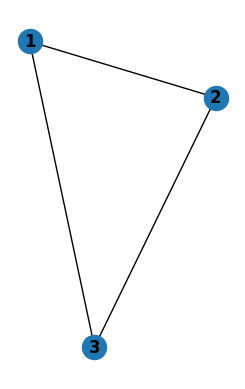

In [5]:
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold')

In [8]:
A = nx.adjacency_matrix(G)
A.toarray()

array([[0, 1, 1],
       [1, 0, 1],
       [1, 1, 0]])

#### Weighted Graphs

In [12]:
G_w = nx.Graph()
G_w.add_edge("a", "b", weight=0.6)
G_w.add_edge("a", "c", weight=0.2)
G_w.add_edge("c", "d", weight=0.1)
G_w.add_edge("c", "e", weight=0.7)
G_w.add_edge("c", "f", weight=0.9)
G_w.add_edge("a", "d", weight=0.3)

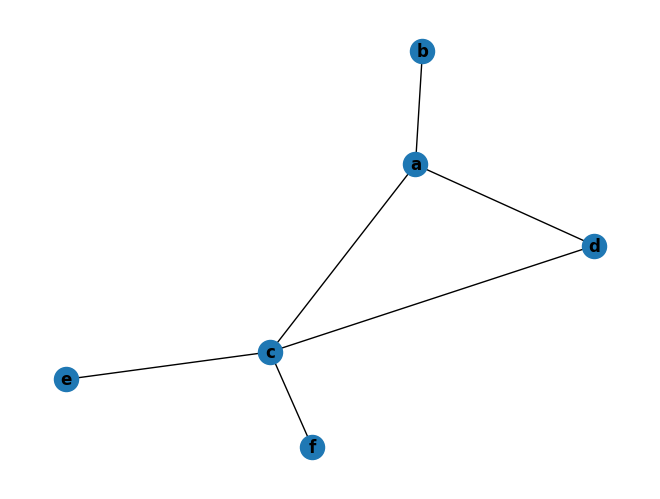

In [19]:
pos = nx.spring_layout(G_w, seed=7)  # positions for all nodes - seed for reproducibility
nx.draw(G_w, with_labels=True, font_weight='bold')

#### 2D Grid Graph

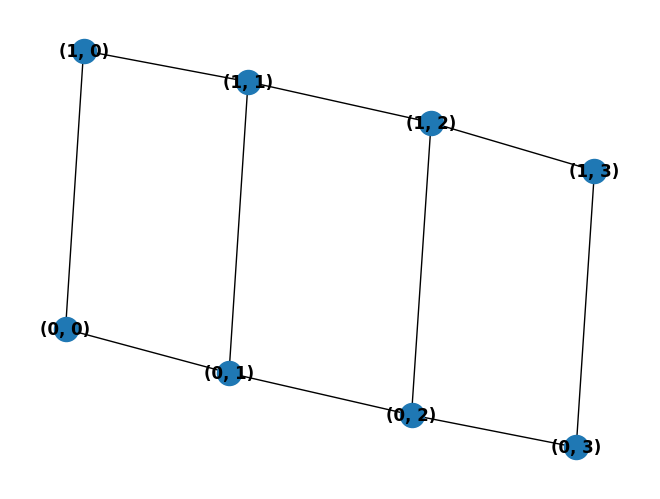

In [22]:
G_grid = nx.grid_2d_graph(2,4)
nx.draw(G_grid, with_labels=True, font_weight='bold')

#### Hypercube Graph

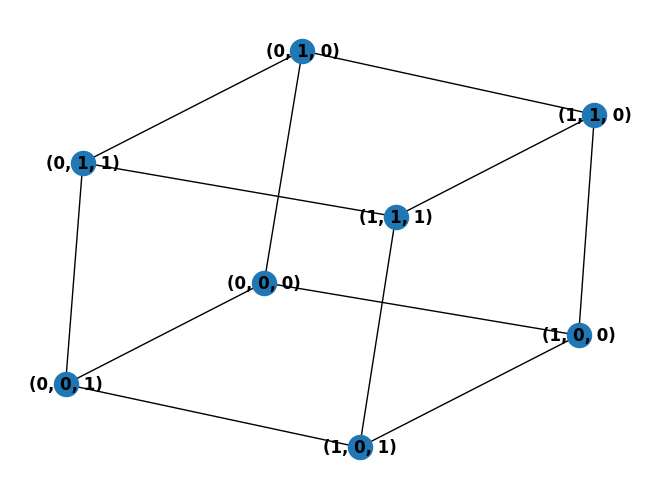

In [26]:
G_hypercube_graph = nx.hypercube_graph(3)
nx.draw(G_hypercube_graph, with_labels=True, font_weight='bold')

#### Complete Multipartite Graph

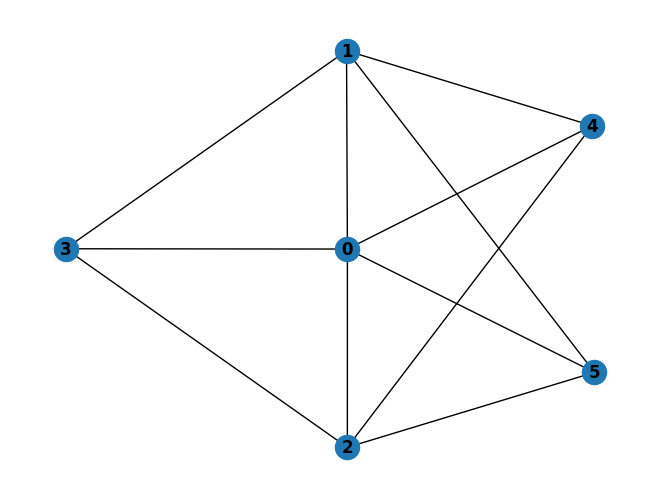

In [28]:
G_multipartite_graph = nx.complete_multipartite_graph(1, 2, 3)
nx.draw(G_multipartite_graph, with_labels=True, font_weight='bold')

### Two Moons

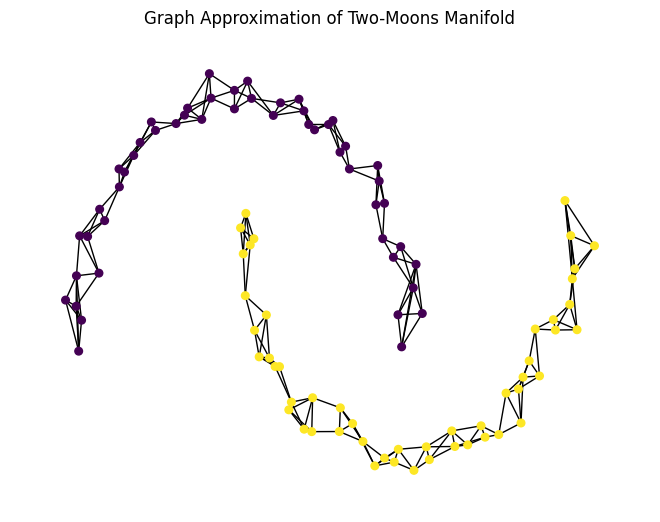

In [38]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors


X, y = make_moons(n_samples=100, noise=0.05, random_state=42)
G = nx.Graph()
for i, pos in enumerate(X):
    G.add_node(i, pos=pos, label=y[i])


nn = NearestNeighbors(n_neighbors=5)
nn.fit(X)
distances, indices = nn.kneighbors(X)

for u, neighbors in enumerate(indices):
    for j, v in enumerate(neighbors[1:]):
        G.add_edge(u, v, weight=distances[u][j+1])


pos = {i: X[i] for i in range(len(X))}
nx.draw(G, pos, node_color=y, node_size=30)
plt.title("Graph Approximation of Two-Moons Manifold")
plt.show()